# QA Tasks Aggregated Analysis

## Executive Summary

**Objective:** Aggregate and compare QA performance across all datasets to answer 3 key questions:

### 🎯 Key Questions:
1. **Which is the best phase for each dataset?**
2. **Which is the best model per phase for each dataset?**
3. **What's the best combination (phase + model) for each dataset?**

**Datasets Included:**
- ✅ **DocVQA_mini** (500 samples, 8 phases) - Document Visual QA
- ✅ **InfographicVQA_mini** (500 samples, 11 phases) - Infographic QA
- ⚠️ **dude_mini** (experimental) - Document Understanding
- ⚠️ **chartqapro_mini** (experimental) - Chart QA

**Evaluation Metrics:**
- 🎯 **PRIMARY: GT in Pred** (Ground Truth in Prediction, higher is better)
- **SECONDARY:** ANLS, Exact Match, Substring Match, Cosine Similarity

**QA Strategies:**
- **QA1 (OCR+VLM):** Two-step pipeline with OCR → LLM
- **QA2 (VLM Parse+QA):** Single VLM does both parsing and QA
- **QA3 (Direct VQA):** VLM sees image directly
- **QA4 (Special):** Dataset-specific approaches


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

from tqdm.notebook import tqdm

# Setup paths
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent.parent.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Import QA metrics
from ocr_vs_vlm.metrics.evaluation_metrics import (
    compute_anls,
    compute_exact_match,
    compute_substring_match,
    compute_ground_truth_in_prediction,
    compute_prediction_in_ground_truth
)
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

# Paths
RESULTS_BASE = REPO_ROOT / 'ocr_vs_vlm' / 'results'
EMBEDDINGS_DIR = RESULTS_BASE / '3_embeddings'

print("✅ Libraries loaded successfully!")
print(f"📂 Results base: {RESULTS_BASE}")


✅ Libraries loaded successfully!
📂 Results base: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results


In [2]:
# QA Dataset configuration
QA_DATASETS = {
    'DocVQA_mini': {
        'path': RESULTS_BASE / '2_clean' / 'DocVQA_mini',
        'phases': ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b'],
        'status': 'production'
    },
    'InfographicVQA_mini': {
        'path': RESULTS_BASE / '2_clean' / 'InfographicVQA_mini',
        'phases': ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b', 'QA4a', 'QA4b', 'QA4c'],
        'status': 'production'
    },
    'dude_mini': {
        'path': RESULTS_BASE / '2_clean' / 'dude_mini',
        'phases': ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b'],
        'status': 'experimental'
    },
    'chartqapro_mini': {
        'path': RESULTS_BASE / '2_clean' / 'chartqapro_mini',
        'phases': ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b'],
        'status': 'experimental'
    }
}

def get_phase_strategy(phase: str) -> str:
    """Get strategy group for phase"""
    if phase.startswith('QA1'): return 'QA1 (OCR+VLM)'
    elif phase.startswith('QA2'): return 'QA2 (VLM Parse+QA)'
    elif phase.startswith('QA3'): return 'QA3 (Direct VQA)'
    elif phase.startswith('QA4'): return 'QA4 (Special)'
    return 'Unknown'

print("📁 QA Dataset Configuration:")
for name, config in QA_DATASETS.items():
    status_icon = '✅' if config['status'] == 'production' else '⚠️'
    print(f"  {status_icon} {name}: {len(config['phases'])} phases")


📁 QA Dataset Configuration:
  ✅ DocVQA_mini: 8 phases
  ✅ InfographicVQA_mini: 11 phases
  ⚠️ dude_mini: 8 phases
  ⚠️ chartqapro_mini: 8 phases


In [3]:
def is_valid_row(row, pred_col: str, err_col: Optional[str] = None) -> bool:
    """Check if prediction is valid"""
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    return True

def parse_ground_truths(gt_string) -> List[str]:
    """Parse ground_truths from JSON string"""
    if pd.isna(gt_string):
        return []
    if isinstance(gt_string, list):
        return gt_string
    try:
        return json.loads(gt_string)
    except:
        return [str(gt_string)]

def calculate_qa_metrics(pred: str, ground_truths: List[str], 
                         phase: str, sample_id: str, model: str,
                         emb_manager: EmbeddingCacheManager) -> Dict:
    """Calculate all QA metrics"""
    if pd.isna(pred) or pred == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'cosine_similarity': 0.0
        }
    
    pred_str = str(pred)
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase, ground_truth=ground_truths[0],
        prediction=pred_str, sample_id=sample_id, model=model
    )
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths),
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'cosine_similarity': float(cosine_sim)
    }

print("✅ Helper functions defined")


✅ Helper functions defined


In [4]:
# Load all QA datasets
all_data = {}
embedding_managers = {}

for dataset_name, config in QA_DATASETS.items():
    print(f"\nLoading {dataset_name}...")
    
    # Initialize embedding manager
    emb_manager = EmbeddingCacheManager(dataset_name, EMBEDDINGS_DIR)
    embedding_managers[dataset_name] = emb_manager
    
    dataset_dfs = {}
    for phase in config['phases']:
        file_path = config['path'] / f"{phase}.csv"
        if file_path.exists():
            df = pd.read_csv(file_path)
            dataset_dfs[phase] = df
            print(f"  ✅ {phase}: {len(df)} samples")
        else:
            print(f"  ⚠️  {phase}: File not found")
    
    all_data[dataset_name] = {
        'config': config,
        'phase_dfs': dataset_dfs
    }

print(f"\n✅ Loaded {len(all_data)} datasets")



Loading DocVQA_mini...
  ✅ QA1a: 500 samples
  ✅ QA1b: 500 samples
  ✅ QA1c: 500 samples
  ✅ QA2a: 500 samples
  ✅ QA2b: 500 samples
  ✅ QA2c: 500 samples
  ✅ QA3a: 500 samples
  ✅ QA3b: 500 samples

Loading InfographicVQA_mini...
  ✅ QA1a: 500 samples
  ✅ QA1b: 500 samples
  ✅ QA1c: 500 samples
  ✅ QA2a: 500 samples
  ✅ QA2b: 500 samples
  ✅ QA2c: 500 samples
  ✅ QA3a: 500 samples
  ✅ QA3b: 500 samples
  ✅ QA4a: 500 samples
  ✅ QA4b: 500 samples
  ✅ QA4c: 500 samples

Loading dude_mini...
  ✅ QA1a: 404 samples
  ✅ QA1b: 404 samples
  ✅ QA1c: 404 samples
  ✅ QA2a: 404 samples
  ✅ QA2b: 404 samples
  ✅ QA2c: 404 samples
  ✅ QA3a: 404 samples
  ✅ QA3b: 404 samples

Loading chartqapro_mini...
  ✅ QA1a: 494 samples
  ✅ QA1b: 494 samples
  ✅ QA1c: 494 samples
  ✅ QA2a: 494 samples
  ✅ QA2b: 494 samples
  ✅ QA2c: 494 samples
  ✅ QA3a: 494 samples
  ✅ QA3b: 494 samples

✅ Loaded 4 datasets


In [5]:
# Calculate QA metrics for all datasets
all_metrics = []

for dataset_name, data in all_data.items():
    if not data['phase_dfs']:
        print(f"⚠️  Skipping {dataset_name} - no data loaded")
        continue
    
    print(f"\nCalculating metrics for {dataset_name}...")
    emb_manager = embedding_managers[dataset_name]
    
    for phase, df in data['phase_dfs'].items():
        pred_cols = [col for col in df.columns if col.startswith('prediction_')]
        
        for pred_col in pred_cols:
            model = pred_col.replace('prediction_', '')
            err_col = f'error_{model}'
            
            # Get valid rows
            valid_rows = [r for _, r in df.iterrows() if is_valid_row(r, pred_col, err_col)]
            
            if not valid_rows:
                continue
            
            # Calculate metrics
            metrics_list = []
            for row in tqdm(valid_rows, desc=f"  {phase}/{model}", leave=False):
                gts = parse_ground_truths(row['ground_truths'])
                m = calculate_qa_metrics(
                    row[pred_col], gts, phase,
                    row['sample_id'], model, emb_manager
                )
                metrics_list.append(m)
            
            # Aggregate
            all_metrics.append({
                'dataset': dataset_name,
                'phase': phase,
                'strategy': get_phase_strategy(phase),
                'model': model,
                'gt_in_pred': np.mean([m['gt_in_pred'] for m in metrics_list]),
                'anls': np.mean([m['anls'] for m in metrics_list]),
                'exact_match': np.mean([m['exact_match'] for m in metrics_list]),
                'substring_match': np.mean([m['substring_match'] for m in metrics_list]),
                'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
                'valid_samples': len(valid_rows)
            })

metrics_df = pd.DataFrame(all_metrics)
print(f"\n✅ Calculated metrics for {len(metrics_df)} combinations")



Calculating metrics for DocVQA_mini...


  QA1a/azure_intelligence__gpt-5-mini:   0%|          | 0/489 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0009, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0023, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0025, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0035, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0038, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini

  QA1a/mistral_document_ai__gpt-5-mini:   0%|          | 0/493 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0003, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0007, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0009, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0013, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0015, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0023, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample docvqa_mini_0025, model mistral_document_ai__gpt-5-mini
Identical embeddings for sample 

...

Invalid cosine similarity -0.0003831122174748902 for sample chartqapro_mini_0195


  QA3a/gpt-5-nano__gpt-5-nano:   0%|          | 0/490 [00:00<?, ?it/s]

  QA3b/gpt-5-mini__gpt-5-mini:   0%|          | 0/493 [00:00<?, ?it/s]

  QA3b/gpt-5-nano__gpt-5-nano:   0%|          | 0/486 [00:00<?, ?it/s]


✅ Calculated metrics for 77 combinations


# General metrics

In [13]:
# Create summary table: datasets (rows) x phases (columns) for 3 metrics
print("="*80)
print("AVERAGE METRICS BY DATASET AND PHASE")
print("="*80)

# Pivot tables for each metric
metrics_to_show = ['gt_in_pred', 'anls', 'cosine_similarity']
metric_names = {'gt_in_pred': 'Ground Truth in Prediction', 'anls': 'ANLS', 'cosine_similarity': 'Cosine Similarity'}

for metric in metrics_to_show:
    print(f"\n📊 {metric_names[metric]}:")
    print("-"*60)
    
    pivot_table = metrics_df.pivot_table(
        index='dataset',
        columns='phase',
        values=metric,
        aggfunc='mean'
    ).round(4)
    
    # Reorder columns by phase name
    phase_order = sorted(pivot_table.columns, key=lambda x: (x[:3], x[3:]))
    pivot_table = pivot_table[phase_order]
    
    display(pivot_table)

# Combined view - create a multi-level table
print("\n" + "="*80)
print("COMBINED SUMMARY TABLE")
print("="*80)

combined_data = []
for dataset in metrics_df['dataset'].unique():
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    for phase in sorted(dataset_data['phase'].unique()):
        phase_data = dataset_data[dataset_data['phase'] == phase]
        combined_data.append({
            'Dataset': dataset,
            'Phase': phase,
            'GT in Pred': round(phase_data['gt_in_pred'].mean(), 4),
            'ANLS': round(phase_data['anls'].mean(), 4),
            'Cosine Sim': round(phase_data['cosine_similarity'].mean(), 4)
        })

combined_df = pd.DataFrame(combined_data)
combined_pivot = combined_df.pivot(index='Dataset', columns='Phase')
display(combined_pivot)

AVERAGE METRICS BY DATASET AND PHASE

📊 Ground Truth in Prediction:
------------------------------------------------------------


phase,QA1a,QA1b,QA1c,QA2a,QA2b,QA2c,QA3a,QA3b,QA4a,QA4b,QA4c
dataset,,,,,,,,,,,
DocVQA_mini,0.8269,0.8546,0.8387,0.7250,0.7267,0.2252,0.8880,0.8979,NaN,NaN,NaN
InfographicVQA_mini,0.5625,0.4751,0.5610,0.6270,0.6295,0.1641,0.6940,0.7048,0.5941,0.5324,0.616
chartqapro_mini,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN
dude_mini,0.5087,0.4703,0.5619,0.4876,0.4431,0.2772,0.4888,0.4975,NaN,NaN,NaN



📊 ANLS:
------------------------------------------------------------


phase,QA1a,QA1b,QA1c,QA2a,QA2b,QA2c,QA3a,QA3b,QA4a,QA4b,QA4c
dataset,,,,,,,,,,,
DocVQA_mini,0.6216,0.8175,0.7198,0.3411,0.4144,0.1951,0.3772,0.4989,NaN,NaN,NaN
InfographicVQA_mini,0.3744,0.4412,0.4587,0.3419,0.3916,0.1371,0.3471,0.1901,0.43,0.5152,0.5284
chartqapro_mini,0.0096,0.0118,0.0075,0.0124,0.0116,0.0078,0.0179,0.0129,NaN,NaN,NaN
dude_mini,0.3498,0.5073,0.0018,0.3451,0.5049,0.0014,0.3631,0.3906,NaN,NaN,NaN



📊 Cosine Similarity:
------------------------------------------------------------


phase,QA1a,QA1b,QA1c,QA2a,QA2b,QA2c,QA3a,QA3b,QA4a,QA4b,QA4c
dataset,,,,,,,,,,,
DocVQA_mini,0.7596,0.8413,0.7963,0.5757,0.6068,0.3778,0.6428,0.7128,NaN,NaN,NaN
InfographicVQA_mini,0.6109,0.5564,0.6335,0.5502,0.5618,0.3640,0.5779,0.4950,0.6739,0.6326,0.724
chartqapro_mini,0.2418,0.2433,0.2407,0.2404,0.2396,0.2313,0.2610,0.2608,NaN,NaN,NaN
dude_mini,0.5940,0.6320,0.3839,0.5823,0.6306,0.2950,0.6029,0.5890,NaN,NaN,NaN



COMBINED SUMMARY TABLE


GT in Pred                                          \
Phase                     QA1a    QA1b    QA1c    QA2a    QA2b    QA2c   
Dataset                                                                  
DocVQA_mini             0.8269  0.8546  0.8387  0.7250  0.7267  0.2252   
InfographicVQA_mini     0.5625  0.4751  0.5610  0.6270  0.6295  0.1641   
chartqapro_mini         0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
dude_mini               0.5087  0.4703  0.5619  0.4876  0.4431  0.2772   

                                                     ... Cosine Sim          \
Phase                  QA3a    QA3b    QA4a    QA4b  ...       QA1b    QA1c   
Dataset                                              ...                      
DocVQA_mini          0.8880  0.8979     NaN     NaN  ...     0.8413  0.7963   
InfographicVQA_mini  0.6940  0.7048  0.5941  0.5324  ...     0.5564  0.6335   
chartqapro_mini      0.0000  0.0000     NaN     NaN  ...     0.2433  0.2407   
dude_mini            0.4888  0.4975     NaN     NaN  ...     0.6320  0.3839   

                                                                             \
Phase                  QA2a    QA2b    QA2c    QA3a    QA3b    QA4a    QA4b   
Dataset                                                                       
DocVQA_mini          0.5757  0.6068  0.3778  0.6428  0.7128     NaN     NaN   
InfographicVQA_mini  0.5502  0.5618  0.3640  0.5779  0.4950  0.6739  0.6326   
chartqapro_mini      0.2404  0.2396  0.2313  0.2610  0.2608     NaN     NaN   
dude_mini            0.5823  0.6306  0.2950  0.6029  0.5890     NaN     NaN   

                            
Phase                 QA4c  
Dataset                     
DocVQA_mini            NaN  
InfographicVQA_mini  0.724  
chartqapro_mini        NaN  
dude_mini              NaN  

[4 rows x 33 columns]

In [14]:
# Create summary table: datasets (rows) x strategies (columns) showing best phase per strategy
print("="*80)
print("BEST METRICS BY DATASET AND STRATEGY")
print("="*80)

# Pivot tables for each metric - aggregating by strategy (max across phases within strategy)
metrics_to_show = ['gt_in_pred', 'anls', 'cosine_similarity']
metric_names = {'gt_in_pred': 'Ground Truth in Prediction', 'anls': 'ANLS', 'cosine_similarity': 'Cosine Similarity'}

for metric in metrics_to_show:
    print(f"\n📊 {metric_names[metric]} (Best per Strategy):")
    print("-"*60)
    
    # Group by dataset and strategy, take max (best) value
    pivot_table = metrics_df.pivot_table(
        index='dataset',
        columns='strategy',
        values=metric,
        aggfunc='max'
    ).round(4)
    
    # Reorder columns by strategy name
    strategy_order = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)', 'QA4 (Special)']
    pivot_table = pivot_table[[col for col in strategy_order if col in pivot_table.columns]]
    
    display(pivot_table)

# Combined view - create a multi-level table with best per strategy
print("\n" + "="*80)
print("COMBINED SUMMARY TABLE (Best per Strategy)")
print("="*80)

combined_data = []
for dataset in metrics_df['dataset'].unique():
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    for strategy in ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)', 'QA4 (Special)']:
        strategy_data = dataset_data[dataset_data['strategy'] == strategy]
        if len(strategy_data) > 0:
            combined_data.append({
                'Dataset': dataset,
                'Strategy': strategy.split(' ')[0],  # Just QA1, QA2, etc.
                'GT in Pred': round(strategy_data['gt_in_pred'].max(), 4),
                'ANLS': round(strategy_data['anls'].max(), 4),
                'Cosine Sim': round(strategy_data['cosine_similarity'].max(), 4)
            })

combined_df = pd.DataFrame(combined_data)
combined_pivot = combined_df.pivot(index='Dataset', columns='Strategy')
display(combined_pivot)

BEST METRICS BY DATASET AND STRATEGY

📊 Ground Truth in Prediction (Best per Strategy):
------------------------------------------------------------


strategy,QA1 (OCR+VLM),QA2 (VLM Parse+QA),QA3 (Direct VQA),QA4 (Special)
dataset,,,,
DocVQA_mini,0.8763,0.8956,0.9080,NaN
InfographicVQA_mini,0.7537,0.7110,0.7851,0.616
chartqapro_mini,0.0000,0.0000,0.0000,NaN
dude_mini,0.5619,0.5545,0.4975,NaN



📊 ANLS (Best per Strategy):
------------------------------------------------------------


strategy,QA1 (OCR+VLM),QA2 (VLM Parse+QA),QA3 (Direct VQA),QA4 (Special)
dataset,,,,
DocVQA_mini,0.8406,0.8683,0.7455,NaN
InfographicVQA_mini,0.6808,0.6257,0.5252,0.5284
chartqapro_mini,0.0163,0.0143,0.0196,NaN
dude_mini,0.5120,0.5049,0.3906,NaN



📊 Cosine Similarity (Best per Strategy):
------------------------------------------------------------


strategy,QA1 (OCR+VLM),QA2 (VLM Parse+QA),QA3 (Direct VQA),QA4 (Special)
dataset,,,,
DocVQA_mini,0.8554,0.8765,0.8300,NaN
InfographicVQA_mini,0.7585,0.7194,0.7136,0.724
chartqapro_mini,0.2553,0.2471,0.2698,NaN
dude_mini,0.6339,0.6306,0.6029,NaN



COMBINED SUMMARY TABLE (Best per Strategy)


GT in Pred                           ANLS                  \
Strategy                   QA1     QA2     QA3    QA4     QA1     QA2     QA3   
Dataset                                                                         
DocVQA_mini             0.8763  0.8956  0.9080    NaN  0.8406  0.8683  0.7455   
InfographicVQA_mini     0.7537  0.7110  0.7851  0.616  0.6808  0.6257  0.5252   
chartqapro_mini         0.0000  0.0000  0.0000    NaN  0.0163  0.0143  0.0196   
dude_mini               0.5619  0.5545  0.4975    NaN  0.5120  0.5049  0.3906   

                            Cosine Sim                         
Strategy                QA4        QA1     QA2     QA3    QA4  
Dataset                                                        
DocVQA_mini             NaN     0.8554  0.8765  0.8300    NaN  
InfographicVQA_mini  0.5284     0.7585  0.7194  0.7136  0.724  
chartqapro_mini         NaN     0.2553  0.2471  0.2698    NaN  
dude_mini               NaN     0.6339  0.6306  0.6029    NaN

## 🎯 Section 3: Best Phase per Dataset

**KEY QUESTION #1: Which is the best phase for each dataset?**

This section identifies the best-performing phase for each dataset based on GT in Pred (PRIMARY metric).


In [6]:
# Identify best phase per dataset
print("="*80)
print("BEST PHASE PER DATASET (by GT in Pred - PRIMARY METRIC)")
print("="*80)

best_phases = []

for dataset in metrics_df['dataset'].unique():
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    
    # Average across models per phase
    phase_avg = dataset_data.groupby('phase').agg({
        'gt_in_pred': 'mean',
        'anls': 'mean',
        'exact_match': 'mean'
    }).round(4)
    
    best_phase = phase_avg['gt_in_pred'].idxmax()
    best_metrics = phase_avg.loc[best_phase]
    
    best_phases.append({
        'Dataset': dataset,
        'Best Phase': best_phase,
        'Strategy': get_phase_strategy(best_phase),
        'GT in Pred': best_metrics['gt_in_pred'],
        'ANLS': best_metrics['anls'],
        'Exact Match': best_metrics['exact_match']
    })
    
    print(f"\n{dataset}:")
    print(f"  🏆 Best Phase: {best_phase} ({get_phase_strategy(best_phase)})")
    print(f"  🎯 GT in Pred: {best_metrics['gt_in_pred']:.4f}")
    print(f"     ANLS: {best_metrics['anls']:.4f}, EM: {best_metrics['exact_match']:.4f}")

best_phases_df = pd.DataFrame(best_phases)
print("\n" + "="*80)
print("SUMMARY TABLE:")
display(best_phases_df)


BEST PHASE PER DATASET (by GT in Pred - PRIMARY METRIC)

DocVQA_mini:
  🏆 Best Phase: QA3b (QA3 (Direct VQA))
  🎯 GT in Pred: 0.8979
     ANLS: 0.4989, EM: 0.3744

InfographicVQA_mini:
  🏆 Best Phase: QA3b (QA3 (Direct VQA))
  🎯 GT in Pred: 0.7048
     ANLS: 0.1901, EM: 0.1203

dude_mini:
  🏆 Best Phase: QA1c (QA1 (OCR+VLM))
  🎯 GT in Pred: 0.5619
     ANLS: 0.0018, EM: 0.0000

chartqapro_mini:
  🏆 Best Phase: QA1a (QA1 (OCR+VLM))
  🎯 GT in Pred: 0.0000
     ANLS: 0.0096, EM: 0.0000

SUMMARY TABLE:


,Dataset,Best Phase,Strategy,GT in Pred,ANLS,Exact Match
0,DocVQA_mini,QA3b,QA3 (Direct VQA),0.8979,0.4989,0.3744
1,InfographicVQA_mini,QA3b,QA3 (Direct VQA),0.7048,0.1901,0.1203
2,dude_mini,QA1c,QA1 (OCR+VLM),0.5619,0.0018,0.0000
3,chartqapro_mini,QA1a,QA1 (OCR+VLM),0.0000,0.0096,0.0000


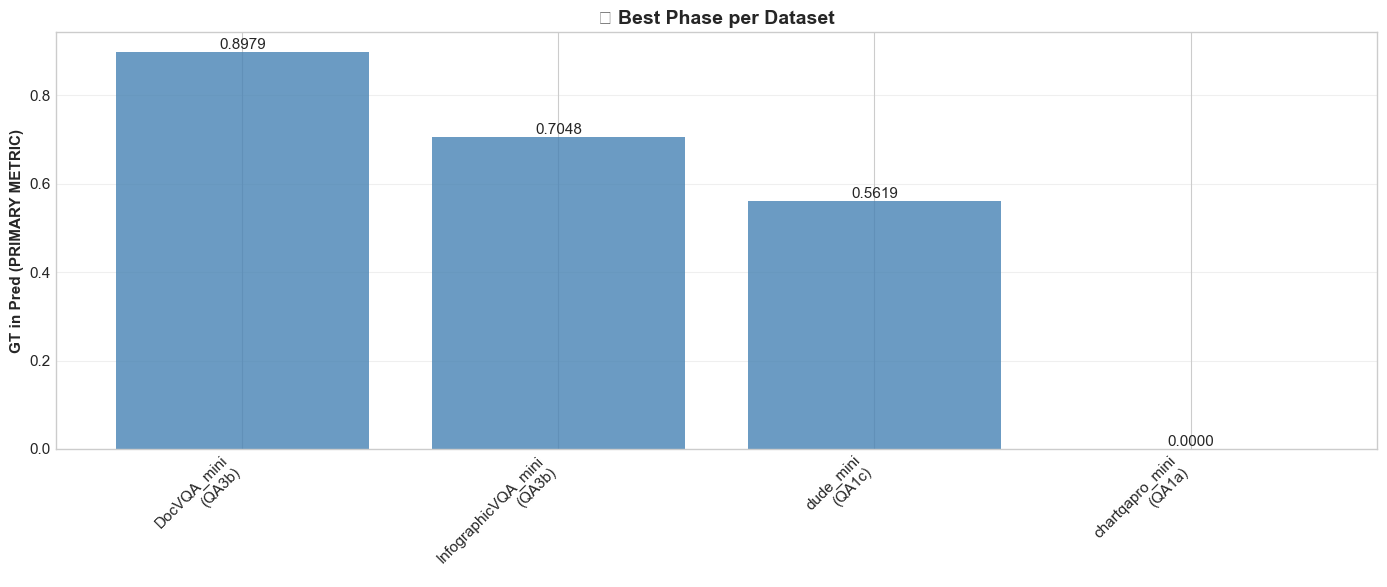

In [7]:
# Visualize best phase per dataset
fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(best_phases_df))
bars = ax.bar(x, best_phases_df['GT in Pred'], color='steelblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f"{row['Dataset']}\n({row['Best Phase']})" 
                     for _, row in best_phases_df.iterrows()], 
                    rotation=45, ha='right')
ax.set_ylabel('GT in Pred (PRIMARY METRIC)', fontweight='bold')
ax.set_title('🏆 Best Phase per Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 🎯 Section 4: Best Model per Phase per Dataset

**KEY QUESTION #2: Which is the best model per phase for each dataset?**

This section identifies the best-performing model for each dataset-phase combination.


In [8]:
# Identify best model per phase per dataset
print("="*80)
print("BEST MODEL PER PHASE PER DATASET")
print("="*80)

best_models_per_phase = []

for dataset in metrics_df['dataset'].unique():
    print(f"\n{dataset}:")
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    
    for phase in sorted(dataset_data['phase'].unique()):
        phase_data = dataset_data[dataset_data['phase'] == phase]
        best_idx = phase_data['gt_in_pred'].idxmax()
        best = phase_data.loc[best_idx]
        
        best_models_per_phase.append({
            'Dataset': dataset,
            'Phase': phase,
            'Strategy': best['strategy'],
            'Best Model': best['model'],
            'GT in Pred': best['gt_in_pred'],
            'ANLS': best['anls'],
            'Exact Match': best['exact_match']
        })
        
        print(f"  {phase}: {best['model'][:30]}... (GT in Pred={best['gt_in_pred']:.4f})")

best_models_df = pd.DataFrame(best_models_per_phase)
print("\n" + "="*80)
print("SUMMARY TABLE:")
display(best_models_df)


BEST MODEL PER PHASE PER DATASET

DocVQA_mini:
  QA1a: azure_intelligence__gpt-5-mini... (GT in Pred=0.8405)
  QA1b: azure_intelligence__gpt-5-mini... (GT in Pred=0.8763)
  QA1c: azure_intelligence__gpt-5-mini... (GT in Pred=0.8571)
  QA2a: claude_sonnet__claude_sonnet... (GT in Pred=0.8778)
  QA2b: gpt-5-mini__gpt-5-mini... (GT in Pred=0.8956)
  QA2c: gpt-5-mini__gpt-5-mini... (GT in Pred=0.8869)
  QA3a: claude_sonnet... (GT in Pred=0.9020)
  QA3b: gpt-5-mini... (GT in Pred=0.9080)

InfographicVQA_mini:
  QA1a: azure_intelligence__gpt-5-mini... (GT in Pred=0.7347)
  QA1b: azure_intelligence__gpt-5-mini... (GT in Pred=0.7302)
  QA1c: azure_intelligence__gpt-5-mini... (GT in Pred=0.7537)
  QA2a: gpt-5-mini__gpt-5-mini... (GT in Pred=0.6923)
  QA2b: gpt-5-mini__gpt-5-mini... (GT in Pred=0.6796)
  QA2c: gpt-5-mini__gpt-5-mini... (GT in Pred=0.7110)
  QA3a: gpt-5-mini... (GT in Pred=0.7776)
  QA3b: gpt-5-mini... (GT in Pred=0.7851)
  QA4a: gpt-5-mini... (GT in Pred=0.5941)
  QA4b: gpt-5-mi

,Dataset,Phase,Strategy,Best Model,GT in Pred,ANLS,Exact Match
0,DocVQA_mini,QA1a,QA1 (OCR+VLM),azure_intelligence__gpt-5-mini,0.840491,0.628352,0.462168
1,DocVQA_mini,QA1b,QA1 (OCR+VLM),azure_intelligence__gpt-5-mini,0.876268,0.840617,0.744422
2,DocVQA_mini,QA1c,QA1 (OCR+VLM),azure_intelligence__gpt-5-mini,0.857143,0.741215,0.571429
3,DocVQA_mini,QA2a,QA2 (VLM Parse+QA),claude_sonnet__claude_sonnet,0.877756,0.013975,0.002004
4,DocVQA_mini,QA2b,QA2 (VLM Parse+QA),gpt-5-mini__gpt-5-mini,0.895582,0.868280,0.779116
5,DocVQA_mini,QA2c,QA2 (VLM Parse+QA),gpt-5-mini__gpt-5-mini,0.886869,0.744284,0.573737
6,DocVQA_mini,QA3a,QA3 (Direct VQA),claude_sonnet,0.902000,0.008897,0.000000
7,DocVQA_mini,QA3b,QA3 (Direct VQA),gpt-5-mini,0.908000,0.632235,0.482000
8,InfographicVQA_mini,QA1a,QA1 (OCR+VLM),azure_intelligence__gpt-5-mini,0.734742,0.501816,0.396714
9,InfographicVQA_mini,QA1b,QA1 (OCR+VLM),azure_intelligence__gpt-5-mini,0.730159,0.680810,0.616780


## 🎯 Section 5: Best Combination per Dataset

**KEY QUESTION #3: What's the best combination (phase + model) for each dataset?**

This section identifies the single best phase-model combination for each dataset.


In [9]:
# Find best combination per dataset
print("="*80)
print("BEST COMBINATION (Phase + Model) PER DATASET")
print("="*80)

best_combinations = []

for dataset in metrics_df['dataset'].unique():
    dataset_data = metrics_df[metrics_df['dataset'] == dataset]
    best_idx = dataset_data['gt_in_pred'].idxmax()
    best = dataset_data.loc[best_idx]
    
    # Get baseline (QA1a) for comparison
    baseline_data = dataset_data[dataset_data['phase'] == 'QA1a']
    if len(baseline_data) > 0:
        baseline_gt = baseline_data['gt_in_pred'].mean()
        improvement = ((best['gt_in_pred'] - baseline_gt) / baseline_gt * 100) if baseline_gt > 0 else 0
    else:
        improvement = 0
    
    best_combinations.append({
        'Dataset': dataset,
        'Best Phase': best['phase'],
        'Strategy': best['strategy'],
        'Best Model': best['model'],
        'GT in Pred': best['gt_in_pred'],
        'ANLS': best['anls'],
        'Exact Match': best['exact_match'],
        'Improvement vs Baseline (%)': round(improvement, 2)
    })
    
    print(f"\n{dataset}:")
    print(f"  🏆 Best Combination: {best['phase']} + {best['model'][:40]}")
    print(f"  🎯 GT in Pred: {best['gt_in_pred']:.4f}")
    print(f"     ANLS: {best['anls']:.4f}, EM: {best['exact_match']:.4f}")
    if improvement != 0:
        print(f"     📈 Improvement vs baseline: {improvement:.2f}%")

best_combinations_df = pd.DataFrame(best_combinations)
print("\n" + "="*80)
print("SUMMARY TABLE:")
display(best_combinations_df)


BEST COMBINATION (Phase + Model) PER DATASET

DocVQA_mini:
  🏆 Best Combination: QA3b + gpt-5-mini
  🎯 GT in Pred: 0.9080
     ANLS: 0.6322, EM: 0.4820
     📈 Improvement vs baseline: 9.80%

InfographicVQA_mini:
  🏆 Best Combination: QA3b + gpt-5-mini
  🎯 GT in Pred: 0.7851
     ANLS: 0.1864, EM: 0.1024
     📈 Improvement vs baseline: 39.57%

dude_mini:
  🏆 Best Combination: QA1c + azure_intelligence__gpt-5-mini
  🎯 GT in Pred: 0.5619
     ANLS: 0.0000, EM: 0.0000
     📈 Improvement vs baseline: 10.46%

chartqapro_mini:
  🏆 Best Combination: QA1a + azure_intelligence__gpt-5-mini
  🎯 GT in Pred: 0.0000
     ANLS: 0.0118, EM: 0.0000

SUMMARY TABLE:


,Dataset,Best Phase,Strategy,Best Model,GT in Pred,ANLS,Exact Match,Improvement vs Baseline (%)
0,DocVQA_mini,QA3b,QA3 (Direct VQA),gpt-5-mini,0.908000,0.632235,0.48200,9.80
1,InfographicVQA_mini,QA3b,QA3 (Direct VQA),gpt-5-mini,0.785141,0.186421,0.10241,39.57
2,dude_mini,QA1c,QA1 (OCR+VLM),azure_intelligence__gpt-5-mini,0.561881,0.000000,0.00000,10.46
3,chartqapro_mini,QA1a,QA1 (OCR+VLM),azure_intelligence__gpt-5-mini,0.000000,0.011826,0.00000,0.00


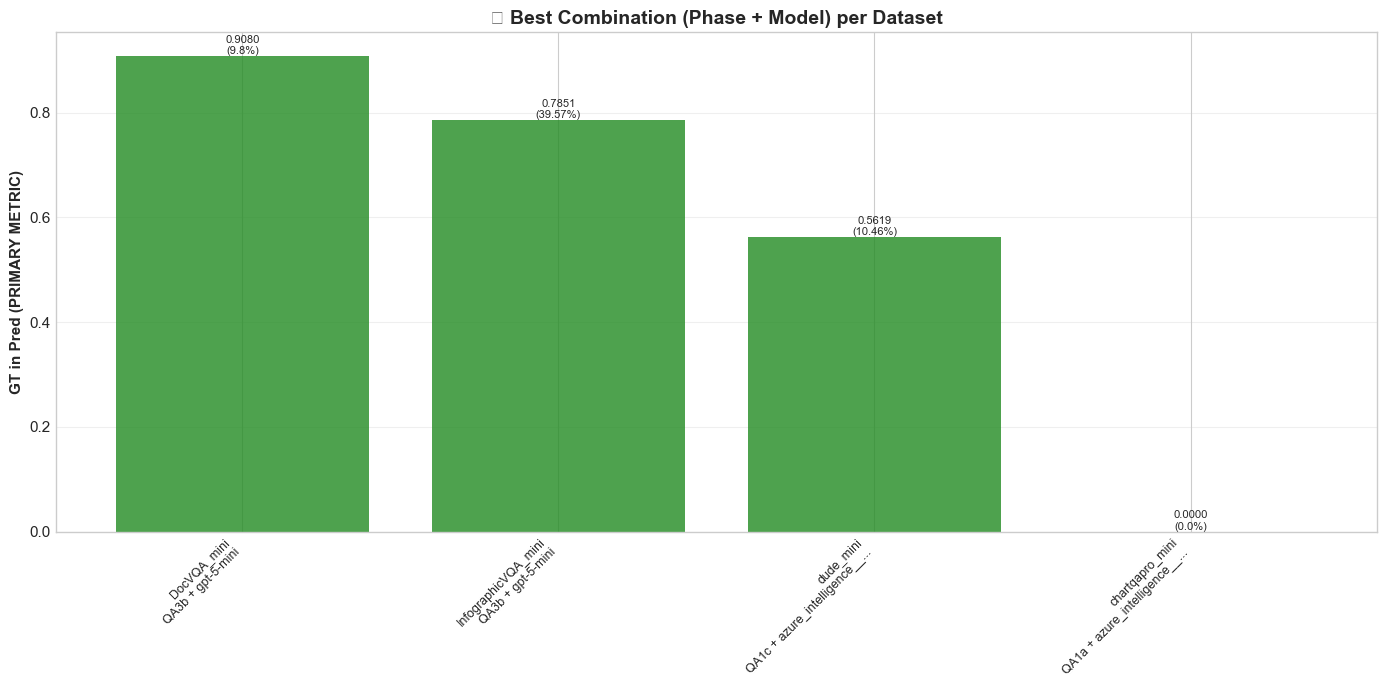

In [10]:
# Visualize best combinations
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(best_combinations_df))
bars = ax.bar(x, best_combinations_df['GT in Pred'], 
              color='forestgreen', alpha=0.8)

ax.set_xticks(x)
labels = []
for _, row in best_combinations_df.iterrows():
    model_short = row['Best Model'][:20] + '...' if len(row['Best Model']) > 20 else row['Best Model']
    labels.append(f"{row['Dataset']}\n{row['Best Phase']} + {model_short}")
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('GT in Pred (PRIMARY METRIC)', fontweight='bold')
ax.set_title('🏆 Best Combination (Phase + Model) per Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    improvement = best_combinations_df.iloc[i]['Improvement vs Baseline (%)']
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}\n({improvement}%)',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


In [11]:
# Export summary tables
output_dir = RESULTS_BASE / '4_notebooks' / 'output'
output_dir.mkdir(exist_ok=True)

best_phases_df.to_csv(output_dir / 'best_phases_qa.csv', index=False)
best_models_df.to_csv(output_dir / 'best_models_per_phase_qa.csv', index=False)
best_combinations_df.to_csv(output_dir / 'best_combinations_qa.csv', index=False)

print("✅ Summary tables exported:")
print(f"   - {output_dir / 'best_phases_qa.csv'}")
print(f"   - {output_dir / 'best_models_per_phase_qa.csv'}")
print(f"   - {output_dir / 'best_combinations_qa.csv'}")


✅ Summary tables exported:
   - /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks/output/best_phases_qa.csv
   - /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks/output/best_models_per_phase_qa.csv
   - /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/4_notebooks/output/best_combinations_qa.csv


## 📊 Strategy Analysis

Compare QA strategies (QA1, QA2, QA3, QA4) across datasets.


In [12]:
# Strategy comparison
print("Strategy Performance Across Datasets:")
print("="*80)

strategy_summary = metrics_df.groupby(['dataset', 'strategy']).agg({
    'gt_in_pred': 'mean',
    'anls': 'mean',
    'exact_match': 'mean'
}).round(4)

display(strategy_summary)

# Overall strategy ranking
overall_strategy = metrics_df.groupby('strategy').agg({
    'gt_in_pred': 'mean',
    'anls': 'mean',
    'exact_match': 'mean'
}).round(4).sort_values('gt_in_pred', ascending=False)

print("\nOverall Strategy Ranking:")
display(overall_strategy)


Strategy Performance Across Datasets:


gt_in_pred    anls  exact_match
dataset             strategy                                           
DocVQA_mini         QA1 (OCR+VLM)           0.8401  0.7196       0.5813
                    QA2 (VLM Parse+QA)      0.4755  0.2864       0.2160
                    QA3 (Direct VQA)        0.8940  0.4502       0.3118
InfographicVQA_mini QA1 (OCR+VLM)           0.5329  0.4248       0.3496
                    QA2 (VLM Parse+QA)      0.3962  0.2519       0.2032
                    QA3 (Direct VQA)        0.6994  0.2686       0.1824
                    QA4 (Special)           0.5808  0.4912       0.4014
chartqapro_mini     QA1 (OCR+VLM)           0.0000  0.0097       0.0000
                    QA2 (VLM Parse+QA)      0.0000  0.0111       0.0000
                    QA3 (Direct VQA)        0.0000  0.0154       0.0000
dude_mini           QA1 (OCR+VLM)           0.5136  0.2863       0.1861
                    QA2 (VLM Parse+QA)      0.3713  0.2132       0.1287
                    QA3 (Direct VQA)        0.4932  0.3769       0.2193


Overall Strategy Ranking:


,gt_in_pred,anls,exact_match
strategy,,,
QA4 (Special),0.5808,0.4912,0.4014
QA3 (Direct VQA),0.5678,0.2752,0.1819
QA1 (OCR+VLM),0.4716,0.3601,0.2792
QA2 (VLM Parse+QA),0.3620,0.2233,0.1680


## 📊 Final Summary

This notebook has answered the 3 key questions:

### ✅ Question 1: Best Phase per Dataset
Identified the optimal phase for each dataset based on GT in Pred (PRIMARY metric).

### ✅ Question 2: Best Model per Phase per Dataset
Identified the best-performing model for each dataset-phase combination.

### ✅ Question 3: Best Combination per Dataset
Identified the single best phase-model combination per dataset with improvement percentages.

**Exported Files:**
- `best_phases_qa.csv` - Best phase per dataset
- `best_models_per_phase_qa.csv` - Best model for each dataset-phase
- `best_combinations_qa.csv` - Best phase-model per dataset

**Key Findings:**
- QA strategies show varying performance across datasets
- Direct VQA (QA3) often performs well for visual reasoning
- OCR+VLM pipeline (QA1) excels for text-heavy documents

**Next Steps:**
- Review [parsing_analysis.ipynb](parsing_analysis.ipynb) for parsing task analysis
- Use results for production model selection
- Refer to individual dataset notebooks in `by_dataset/` for detailed analysis
